In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("HR_comma_sep.csv")

In [3]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


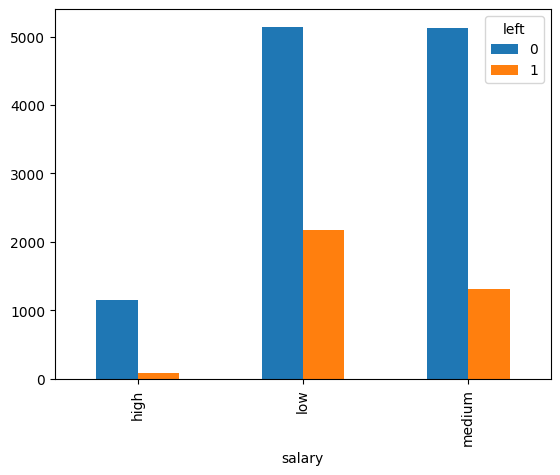

In [5]:
pd.crosstab(df.salary , df.left).plot(kind='bar')
plt.show()

In [6]:
df.dept.unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

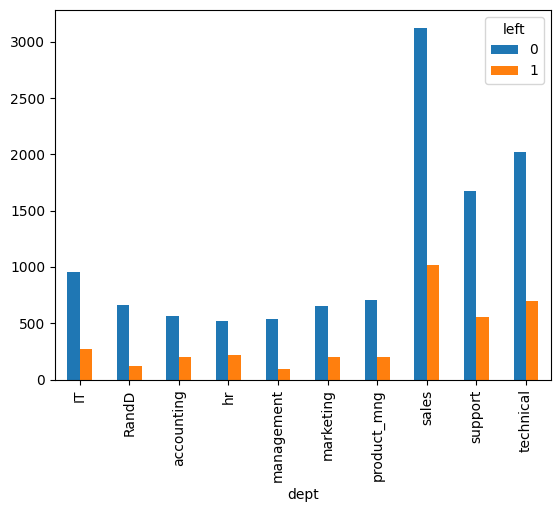

In [8]:
pd.crosstab(df.dept , df.left).plot(kind = 'bar')
plt.show()

In [9]:
left = df[df.left == 1]

In [11]:
left.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [12]:
retained = df[df.left == 0]
retained.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
2000,0.58,0.74,4,215,3,0,0,0,sales,low
2001,0.82,0.67,2,202,3,0,0,0,sales,low
2002,0.45,0.69,5,193,3,0,0,0,sales,low
2003,0.78,0.82,5,247,3,0,0,0,sales,low
2004,0.49,0.60,3,214,2,0,0,0,sales,low


In [14]:
retained.shape

(11428, 10)

In [15]:
left.shape

(3571, 10)

In [16]:
df.shape

(14999, 10)

In [18]:
avg = df.groupby('left').mean(numeric_only=True)
avg

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


In [19]:
subdf = df[['satisfaction_level' , 'average_montly_hours' , 'promotion_last_5years' ,'salary']]

In [20]:
subdf.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [23]:
salary_dummies = pd.get_dummies(subdf.salary , prefix = 'salary').astype('int')

In [24]:
salary_dummies

,salary_high,salary_low,salary_medium
0,0,1,0
1,0,0,1
2,0,0,1
3,0,1,0
4,0,1,0
...,...,...,...
14994,0,1,0
14995,0,1,0
14996,0,1,0
14997,0,1,0


In [33]:
df_with_dummies = pd.concat([subdf.drop('salary', axis=1), salary_dummies], axis=1)

In [34]:
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,0,1,0
1,0.80,262,0,0,0,1
2,0.11,272,0,0,0,1
3,0.72,223,0,0,1,0
4,0.37,159,0,0,1,0


In [35]:
x = df_with_dummies
y = df.left

In [36]:
from sklearn.model_selection  import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size = 0.3)

In [37]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [38]:
model.fit(x_train , y_train)

C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
model.score(x_test , y_test)

C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.23844444444444443

In [42]:
x_test_scaled = scaler.transform(x_test)

In [43]:
model.score(x_test_scaled, y_test)

0.7751111111111111

In [45]:
import joblib

# Model save
joblib.dump(model, 'hr_attrition_model.pkl')

# Scaler save
joblib.dump(scaler, 'hr_scaler.pkl')

['hr_scaler.pkl']

In [47]:
import joblib

model = joblib.load('hr_attrition_model.pkl')
scaler = joblib.load('hr_scaler.pkl')

In [52]:
scaler.feature_names_in_

array(['satisfaction_level', 'average_montly_hours',
       'promotion_last_5years', 'salary_high', 'salary_low',
       'salary_medium'], dtype=object)

In [53]:
import pandas as pd

inputs = pd.DataFrame([[0.48, 288, 0, 0, 0, 1]],
columns=[
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'salary_high',
    'salary_low',
    'salary_medium'
])

In [54]:
inputs_scaled = scaler.transform(inputs)

prediction = model.predict(inputs_scaled)
probability = model.predict_proba(inputs_scaled)

print("Prediction:", prediction)

Prediction: [0]


In [55]:
print("Probability:", probability)

Probability: [[0.69202759 0.30797241]]


In [57]:
y_pred = model.predict(x_test_scaled)

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3199  228]
 [ 784  289]]


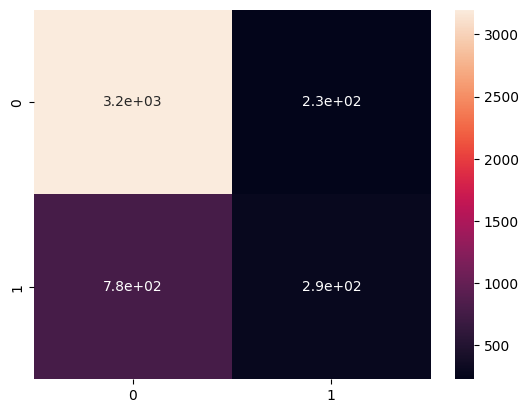

In [60]:
sns.heatmap(cm ,annot = True)
plt.show()

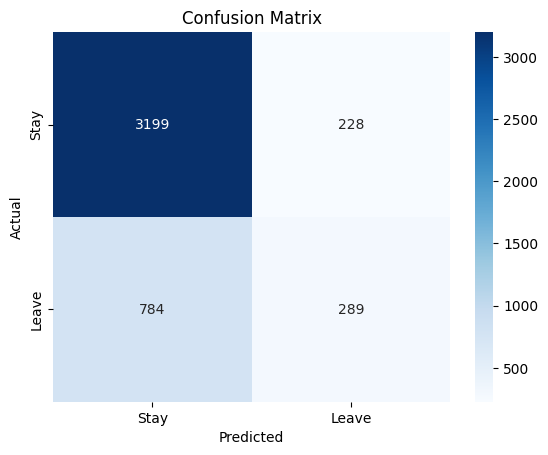

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()